# PRACTICAL EXAM

IMPORT LIBRARIES

In [51]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import sqlite3 
import json
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

LOAD CSV

In [52]:
df = pd.read_csv(r"D:\Python_rnw\one\Data-PreProcessing & Feature Engineering\practical_exam\users_with_missing_and_outliers.csv")
df.head()

,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35.0,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30.0,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37.0,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44.0,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30.0,Other,Chennai,2024-01-04


In [53]:
df_before = df.copy()   

LOAD JSON

In [54]:
sales = pd.read_json("D:\Python_rnw\one\Data-PreProcessing & Feature Engineering\practical_exam\sales.json")
sales.head()

,transaction_id,user_id,product_id,amount,payment_type,date
0,T000001,U0024,P015,67.67,Wallet,2023-02-12
1,T000002,U0196,P044,76.44,UPI,2023-03-24
2,T000003,U0196,P049,104.57,Debit Card,2025-08-21
3,T000004,U0133,P042,102.75,Net Banking,2024-07-23
4,T000005,U0047,P038,23.89,Net Banking,2025-10-04


LOAD SQL

In [55]:
conn = sqlite3.connect("inventory.db")

df.to_sql("inventory", conn, if_exists="replace", index=False)


sql = pd.read_sql("SELECT * FROM inventory", conn)
sql.head()

,user_id,name,age,gender,city,registration_date
0,U0001,Vihaan Sharma,35.0,Other,Jaipur,2022-09-08
1,U0002,Sai Reddy,30.0,Other,Hyderabad,2023-11-24
2,U0003,Aarohi Gupta,37.0,Other,Indore,2022-02-02
3,U0004,Aarav Gupta,44.0,Male,Kolkata,2023-06-02
4,U0005,Sara Sharma,30.0,Other,Chennai,2024-01-04


In [56]:
df.tail()

,user_id,name,age,gender,city,registration_date
195,U0196,Kabir Kulkarni,35.0,Other,Patna,2024-08-01
196,U0197,Kabir Roy,24.0,Male,Thane,2023-12-07
197,U0198,Kabir Bose,33.0,Female,Visakhapatnam,2023-07-07
198,U0199,Meera Roy,32.0,Male,Ghaziabad,2022-02-10
199,U0200,Kiara Nair,22.0,Other,Jaipur,2022-01-27


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            195 non-null    str    
 1   name               200 non-null    str    
 2   age                195 non-null    float64
 3   gender             200 non-null    str    
 4   city               200 non-null    str    
 5   registration_date  200 non-null    str    
dtypes: float64(1), str(5)
memory usage: 9.5 KB


In [58]:
df.shape

(200, 6)

In [59]:
df.describe()

,age
count,195.000000
mean,31.725444
std,25.548679
min,-163.538462
25%,26.000000
50%,32.000000
75%,35.500000
max,312.000000


In [60]:
#identify missing values in each column
mv= df.isnull().sum()
mp = (mv/len(df))*100

ms =  pd.DataFrame({
    "Missing Value": mv,
    "Missing Percentage(%)": mp.round(2)
})
ms

,Missing Value,Missing Percentage(%)
user_id,5,2.5
name,0,0.0
age,5,2.5
gender,0,0.0
city,0,0.0
registration_date,0,0.0


HANDLING MISSING VALUE

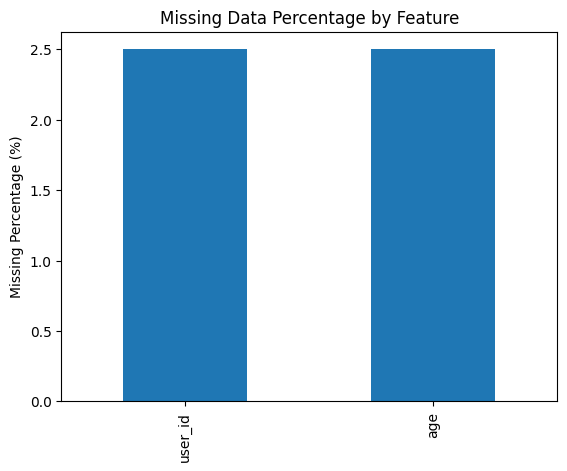

In [61]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values().plot(kind="bar")
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Data Percentage by Feature")
plt.show()

NUMERICAL

In [62]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])

In [63]:
print("\nMissing values after imputation:\n")
print(df.isnull().sum())

print("\nNumerical Summary After:\n")
print(df.describe())


Missing values after imputation:

user_id              5
name                 0
age                  0
gender               0
city                 0
registration_date    0
dtype: int64

Numerical Summary After:

              age
count  200.000000
mean    31.725444
std     25.225674
min   -163.538462
25%     26.000000
50%     31.725444
75%     35.000000
max    312.000000


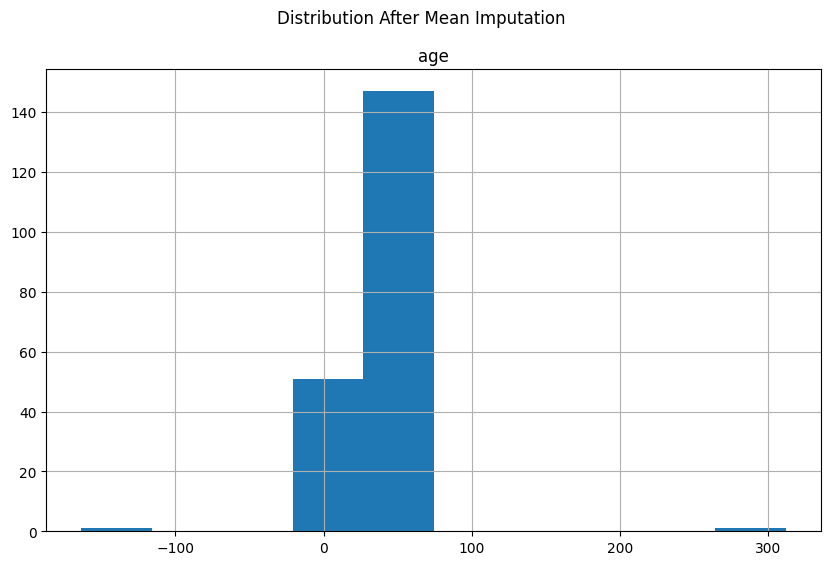

In [64]:
import matplotlib.pyplot as plt

df[num_cols].hist(figsize=(10,6))
plt.suptitle("Distribution After Mean Imputation")
plt.show()

Missing numerical values were handled using mean imputation.
After applying SimpleImputer, missing counts reduced to zero.
Statistical summary confirms dataset consistency without major distortion.

CATEGORICAL

In [65]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols.tolist())

Categorical Columns: ['user_id', 'name', 'gender', 'city', 'registration_date']


C:\Users\Admin\AppData\Local\Temp\ipykernel_5504\436091374.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [66]:
print("Missing values BEFORE imputation:\n")
print(df[cat_cols].isnull().sum())

Missing values BEFORE imputation:

user_id              5
name                 0
gender               0
city                 0
registration_date    0
dtype: int64


Apply Most Frequent Imputation

In [67]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [68]:
print("\nMissing values AFTER imputation:\n")
print(df[cat_cols].isnull().sum())


Missing values AFTER imputation:

user_id              0
name                 0
gender               0
city                 0
registration_date    0
dtype: int64


Categorical missing values were handled using most frequent imputation.
The method replaces missing entries with the mode of the column, preserving category distribution while removing null values.

Apply KNN Imputer

Select Numerical Columns

KNN works only on numeric data.

In [69]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:", num_cols.tolist())

Numerical Columns: ['age']


In [70]:
print("Missing values BEFORE KNN:\n")
print(df[num_cols].isnull().sum())

print("\nStatistical Summary BEFORE:\n")
print(df[num_cols].describe())

Missing values BEFORE KNN:

age    0
dtype: int64

Statistical Summary BEFORE:

              age
count  200.000000
mean    31.725444
std     25.225674
min   -163.538462
25%     26.000000
50%     31.725444
75%     35.000000
max    312.000000


Apply KNN Imputer

In [71]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

df_knn = df.copy()
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

AFTER

In [72]:
print("\nMissing values AFTER KNN:\n")
print(df_knn[num_cols].isnull().sum())

print("\nStatistical Summary AFTER:\n")
print(df_knn[num_cols].describe())


Missing values AFTER KNN:

age    0
dtype: int64

Statistical Summary AFTER:

              age
count  200.000000
mean    31.725444
std     25.225674
min   -163.538462
25%     26.000000
50%     31.725444
75%     35.000000
max    312.000000


In [73]:
rows_with_nan = df[num_cols].isnull().any(axis=1)

print("Before KNN:\n")
print(df.loc[rows_with_nan, num_cols])

print("\nAfter KNN:\n")
print(df_knn.loc[rows_with_nan, num_cols])

Before KNN:

Empty DataFrame
Columns: [age]
Index: []

After KNN:

Empty DataFrame
Columns: [age]
Index: []


fixing invalid or inconsistent entries

Checking Dtype of each column

In [74]:
print("Data Types:\n")
print(df.dtypes)

print("\nSummary Statistics:\n")
print(df.describe(include='all'))

print("\nNegative values check:\n")
print((df.select_dtypes(include=['int64','float64']) < 0).sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Data Types:

user_id                  str
name                     str
age                  float64
gender                   str
city                     str
registration_date        str
dtype: object

Summary Statistics:

       user_id      name         age gender     city registration_date
count      200       200  200.000000    200      200               200
unique     195       160         NaN      3       20               188
top      U0001  Sai Iyer         NaN   Male  Kolkata        2022-12-15
freq         6         3         NaN     71       18                 2
mean       NaN       NaN   31.725444    NaN      NaN               NaN
std        NaN       NaN   25.225674    NaN      NaN               NaN
min        NaN       NaN -163.538462    NaN      NaN               NaN
25%        NaN       NaN   26.000000    NaN      NaN               NaN
50%        NaN       NaN   31.725444    NaN      NaN               NaN
75%        NaN       NaN   35.000000    NaN      NaN               

Columns:

In [75]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['user_id', 'name', 'age', 'gender', 'city', 'registration_date'], dtype='str')


In [76]:
print("Before conversion:")
print(df["registration_date"].head())
print("\nDatatype:", df["registration_date"].dtype)

Before conversion:
0    2022-09-08
1    2023-11-24
2    2022-02-02
3    2023-06-02
4    2024-01-04
Name: registration_date, dtype: str

Datatype: str


In [77]:
df["registration_date"] = pd.to_datetime(
    df["registration_date"],
    errors="coerce"   # invalid dates → NaT
)

In [78]:
print("\nAfter conversion:")
print("Datatype:", df["registration_date"].dtype)

print("\nInvalid dates converted to NaT:")
print(df["registration_date"].isnull().sum())


After conversion:
Datatype: datetime64[us]

Invalid dates converted to NaT:
0


Fix Invalid Age Values

In [79]:
print("Invalid ages BEFORE:")
print(((df["age"] < 0) | (df["age"] > 100)).sum())

Invalid ages BEFORE:
2


In [80]:
df.loc[(df["age"] < 0) | (df["age"] > 100), "age"] = None

In [81]:
print("Invalid age count AFTER:")
print(((df["age"] < 0) | (df["age"] > 100)).sum())

Invalid age count AFTER:
0


Clean Gender Column (Inconsistent Categories)

In [82]:
print("Gender values:")
print(df["gender"].value_counts(dropna=False))


Gender values:
gender
Male      71
Female    65
Other     64
Name: count, dtype: int64


Clean City Column (Extra Spaces / Case Issues)

In [83]:
print("City values:")
print(df["city"].unique())

City values:
<StringArray>
[       'Jaipur',     'Hyderabad',        'Indore',       'Kolkata',
       'Chennai',         'Thane',       'Lucknow',        'Kanpur',
         'Delhi',        'Nagpur',     'Ghaziabad',     'Bengaluru',
          'Pune',         'Patna',        'Bhopal',     'Ahmedabad',
 'Visakhapatnam',         'Surat',      'Vadodara',        'Mumbai']
Length: 20, dtype: str


Everything's good 

Remove Duplicate Users

In [84]:
print("Duplicate rows BEFORE:", df.duplicated().sum())

Duplicate rows BEFORE: 0


No Duplicate User

Invalid entries including incorrect date formats, unrealistic age values, inconsistent categorical formatting, and duplicate records were identified and corrected to improve dataset integrity and reliability.

UNIVARIATE ANALYSIS (Single Variable)

A. Numerical (Age)

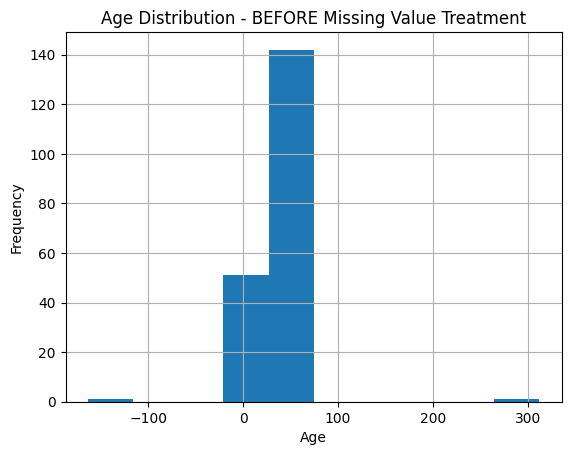

In [85]:
import matplotlib.pyplot as plt

plt.figure()
df_before["age"].hist()
plt.title("Age Distribution - BEFORE Missing Value Treatment")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

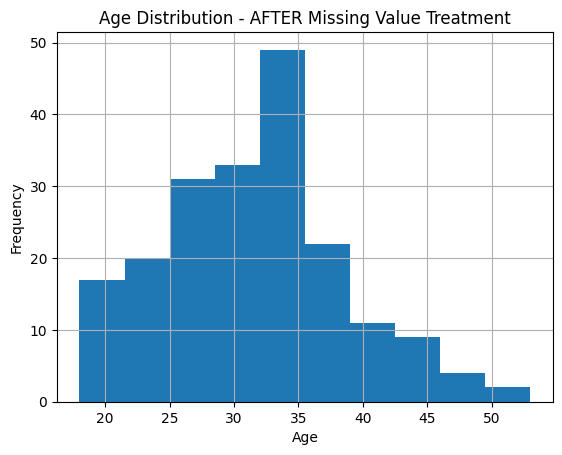

In [86]:
plt.figure()
df["age"].hist()
plt.title("Age Distribution - AFTER Missing Value Treatment")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Distribution stabilized after missing value treatment.

BIVARIATE ANALYSIS (Two Variables)

Age vs Gender (Boxplot)

<Figure size 640x480 with 0 Axes>

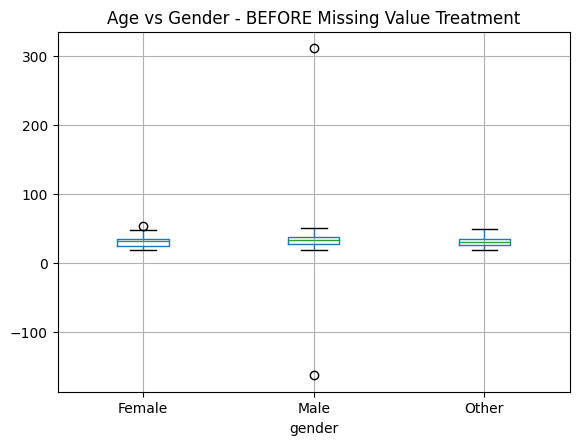

In [87]:
plt.figure()
df_before.boxplot(column="age", by="gender")
plt.title("Age vs Gender - BEFORE Missing Value Treatment")
plt.suptitle("")
plt.show()

<Figure size 640x480 with 0 Axes>

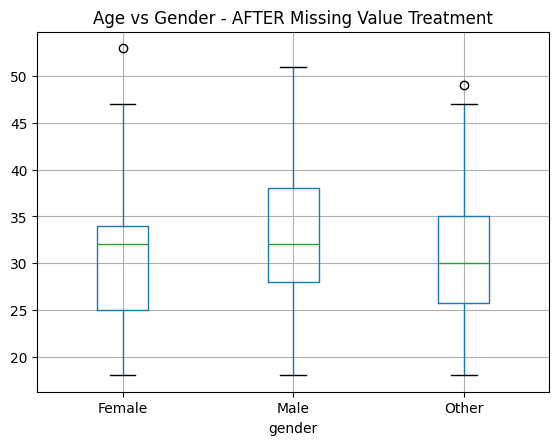

In [88]:
plt.figure()
df.boxplot(column="age", by="gender")
plt.title("Age vs Gender - AFTER Missing Value Treatment")
plt.suptitle("")
plt.show()

Group-level patterns became clearer without null distortions.

MULTIVARIATE ANALYSIS (More Than Two Variables)

In [89]:
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")

In [90]:
df["year"] = df["registration_date"].dt.year

In [91]:
print(df.columns)

Index(['user_id', 'name', 'age', 'gender', 'city', 'registration_date',
       'year'],
      dtype='str')


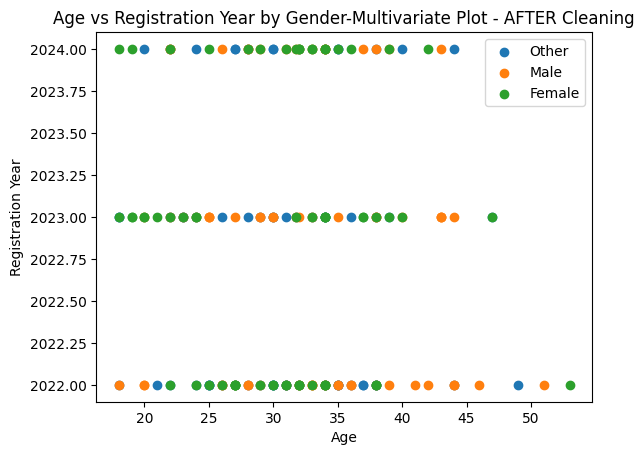

In [92]:
plt.figure()
for g in df["gender"].unique():
    subset = df[df["gender"] == g]
    plt.scatter(subset["age"], subset["year"], label=g)

plt.legend()
plt.xlabel("Age")
plt.ylabel("Registration Year")
plt.title("Age vs Registration Year by Gender-Multivariate Plot - AFTER Cleaning")
plt.show()

The distribution shows how different age groups registered across various years.

Clusters of points indicate dominant registration periods.

Gender-based separation helps identify whether certain age groups within a gender registered more frequently in specific years.

After missing value treatment and feature extraction, the dataset allows meaningful multivariate analysis

OUTLIERS HANDLING

Calculate Z-score

In [93]:
from scipy.stats import zscore
import numpy as np

df_z = df.copy()

df_z["z_score"] = zscore(df_z["age"])

# Identify outliers (|z| > 3)
z_outliers = df_z[np.abs(df_z["z_score"]) > 3]

print("Z-Score Outliers Count:", z_outliers.shape[0])

Z-Score Outliers Count: 0


Visualize Z-score Detection

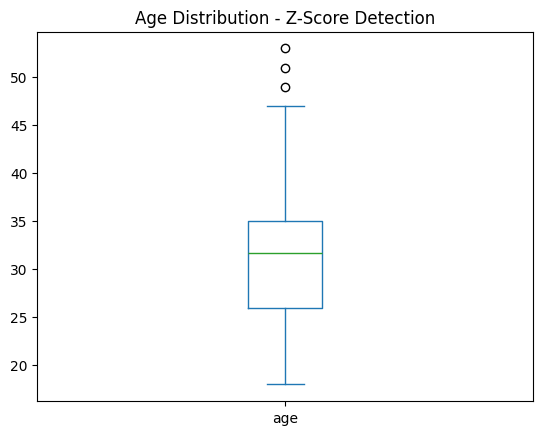

In [94]:
import matplotlib.pyplot as plt

plt.figure()
df_z["age"].plot(kind="box")
plt.title("Age Distribution - Z-Score Detection")
plt.show()

Detect Outliers Using IQR

In [95]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df[(df["age"] < lower) | (df["age"] > upper)]

print("IQR Outliers Count:", iqr_outliers.shape[0])

IQR Outliers Count: 3


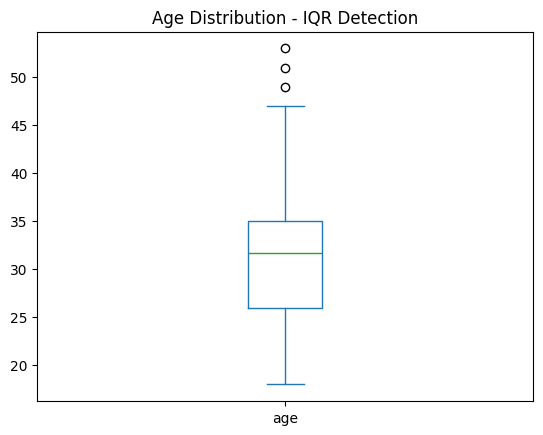

In [96]:
plt.figure()
df["age"].plot(kind="box")
plt.title("Age Distribution - IQR Detection")
plt.show()

Comparing Both

In [97]:
print("Z-Score Outliers:", z_outliers.shape[0])
print("IQR Outliers:", iqr_outliers.shape[0])

Z-Score Outliers: 0
IQR Outliers: 3


Checking Skewness

In [98]:
print("Skewness of Age:", df["age"].skew())

Skewness of Age: 0.2562994561073281


In [99]:
df_winsor = df.copy()

df_winsor["age"] = df_winsor["age"].clip(lower, upper)

Winsorization using IQR bounds

In [101]:
df_winsor = df.copy()

df_winsor["age"] = df_winsor["age"].clip(lower, upper)

In [102]:
final_outliers = df_winsor[
    (df_winsor["age"] < lower) | 
    (df_winsor["age"] > upper)
]

print("Outliers After Winsorization:", final_outliers.shape[0])

Outliers After Winsorization: 0


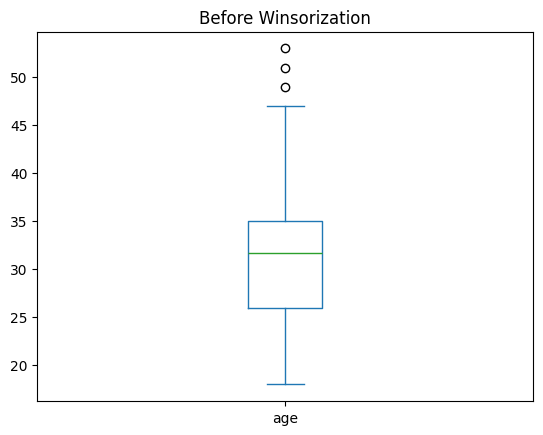

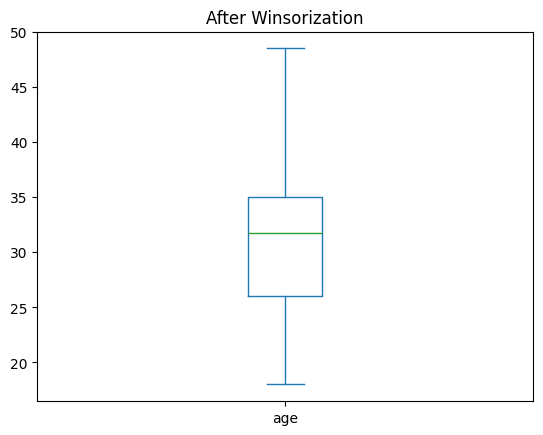

In [103]:
plt.figure()
df["age"].plot(kind="box")
plt.title("Before Winsorization")
plt.show()
plt.figure()
df_winsor["age"].plot(kind="box")
plt.title("After Winsorization")
plt.show()

Outliers were detected using both Z-score and IQR methods.
Since the age distribution showed skewness and did not follow strict normality, the IQR method was considered more robust and appropriate.
Instead of removing records, Winsorization was applied to cap extreme values, preserving dataset size while reducing distortion.

In [104]:
print("Mean Before:", df["age"].mean())
print("Mean After:", df_winsor["age"].mean())

Mean Before: 31.296097065327835
Mean After: 31.258218277449046


4. Data Tranformation

In [105]:
print("Datatype:", df["registration_date"].dtype)

print("\nSample Values BEFORE:")
print(df["registration_date"].head())

Datatype: datetime64[us]

Sample Values BEFORE:
0   2022-09-08
1   2023-11-24
2   2022-02-02
3   2023-06-02
4   2024-01-04
Name: registration_date, dtype: datetime64[us]


Extract Year, Month, Day

In [106]:
df["reg_year"] = df["registration_date"].dt.year
df["reg_month"] = df["registration_date"].dt.month
df["reg_day"] = df["registration_date"].dt.day

New Columns Created

In [107]:
print("\nColumns After Feature Extraction:")
print(df.columns)

print("\nSample Rows After Transformation:")
print(df[["registration_date", "reg_year", "reg_month", "reg_day"]].head())


Columns After Feature Extraction:
Index(['user_id', 'name', 'age', 'gender', 'city', 'registration_date', 'year',
       'reg_year', 'reg_month', 'reg_day'],
      dtype='str')

Sample Rows After Transformation:
  registration_date  reg_year  reg_month  reg_day
0        2022-09-08      2022          9        8
1        2023-11-24      2023         11       24
2        2022-02-02      2022          2        2
3        2023-06-02      2023          6        2
4        2024-01-04      2024          1        4


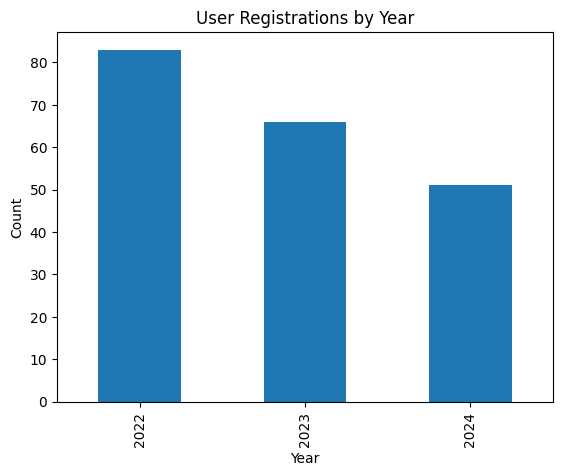

In [108]:
plt.figure()
df["reg_year"].value_counts().sort_index().plot(kind="bar")
plt.title("User Registrations by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

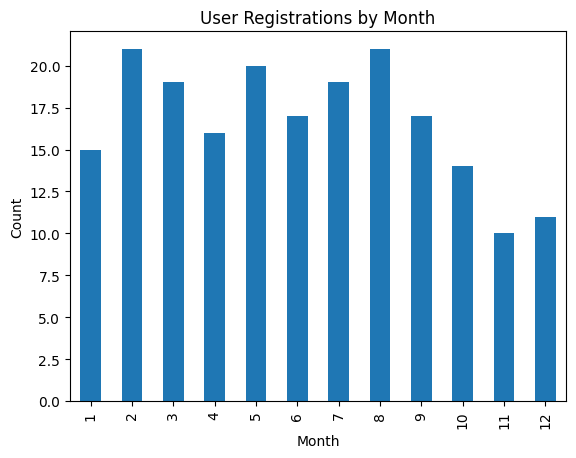

In [109]:
plt.figure()
df["reg_month"].value_counts().sort_index().plot(kind="bar")
plt.title("User Registrations by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

The registration_date column was transformed into separate year, month, and day features to enable time-based analysis. This transformation improves interpretability and enhances feature usefulness for predictive modeling.

Encoding

Identifing Categorical Columns

In [110]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols.tolist())

Categorical Columns: ['user_id', 'name', 'gender', 'city']


C:\Users\Admin\AppData\Local\Temp\ipykernel_5504\436091374.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


One-Hot Encoding

In [111]:
df = pd.get_dummies(df, columns=["gender"], drop_first=True)

print(df.head())

  user_id           name   age       city registration_date  year  reg_year  \
0   U0001  Vihaan Sharma  35.0     Jaipur        2022-09-08  2022      2022   
1   U0002      Sai Reddy  30.0  Hyderabad        2023-11-24  2023      2023   
2   U0003   Aarohi Gupta  37.0     Indore        2022-02-02  2022      2022   
3   U0004    Aarav Gupta  44.0    Kolkata        2023-06-02  2023      2023   
4   U0005    Sara Sharma  30.0    Chennai        2024-01-04  2024      2024   

   reg_month  reg_day  gender_Male  gender_Other  
0          9        8        False          True  
1         11       24        False          True  
2          2        2        False          True  
3          6        2         True         False  
4          1        4        False          True  


In [114]:
print(df.columns)

Index(['user_id', 'name', 'age', 'city', 'registration_date', 'year',
       'reg_year', 'reg_month', 'reg_day', 'gender_Male', 'gender_Other'],
      dtype='str')


In [115]:
if "gender" in df.columns:
    print("Column exists")
else:
    print("Column already encoded or removed")

Column already encoded or removed


LOG TRANSFORMATION

Checking Skewness

In [116]:
print(df["age"].skew())

0.2562994561073281


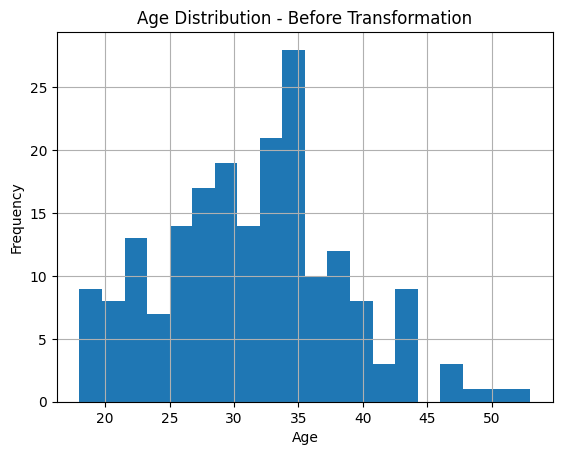

In [117]:
plt.figure()
df["age"].hist(bins=20)
plt.title("Age Distribution - Before Transformation")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [118]:
df["age_log"] = np.log1p(df["age"])

In [119]:
print("Skewness after log:", df["age_log"].skew())

Skewness after log: -0.3136722082321614


Square Root Transformation

In [120]:
df["age_sqrt"] = np.sqrt(df["age"])

print("Skewness after sqrt:", df["age_sqrt"].skew())

Skewness after sqrt: -0.04468182335551694


Comparing Both

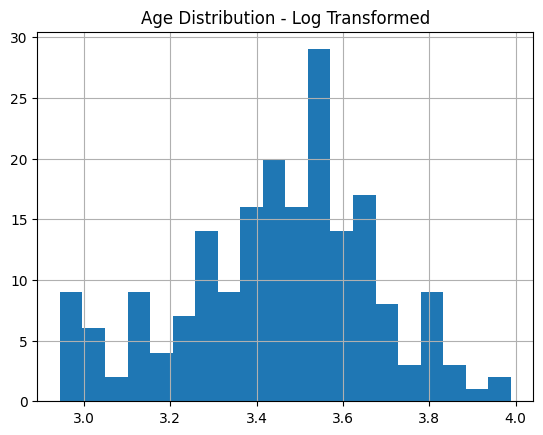

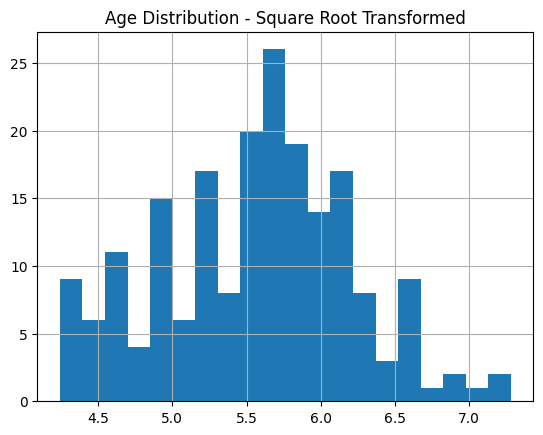

In [121]:
plt.figure()
df["age_log"].hist(bins=20)
plt.title("Age Distribution - Log Transformed")
plt.show()

plt.figure()
df["age_sqrt"].hist(bins=20)
plt.title("Age Distribution - Square Root Transformed")
plt.show()

In [122]:
print("Original:", df["age"].skew())
print("Log:", df["age_log"].skew())
print("Sqrt:", df["age_sqrt"].skew())

Original: 0.2562994561073281
Log: -0.3136722082321614
Sqrt: -0.04468182335551694


The age variable showed low skewness (0.256), indicating near-normal distribution. Log and square root transformations were applied for comparison. Square root transformation reduced skewness slightly (-0.045), but since the original skewness was already minimal, no transformation was retained.

Feature Scalling

Identifing Numerical Columns

In [123]:
print(df.select_dtypes(include=["int64", "float64"]).columns)

Index(['age', 'age_log', 'age_sqrt'], dtype='str')


Standard Scaler

In [124]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

df["age_standard"] = scaler_std.fit_transform(df[["age"]])

print(df[["age", "age_standard"]].head())

    age  age_standard
0  35.0      0.523487
1  30.0     -0.183182
2  37.0      0.806154
3  44.0      1.795491
4  30.0     -0.183182


Check Mean & Std:

In [125]:
print("Mean:", df["age_standard"].mean())
print("Std:", df["age_standard"].std())

Mean: -9.420074148334662e-17
Std: 1.0025348583126572


MinMax Scaler

In [126]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

df["age_minmax"] = scaler_mm.fit_transform(df[["age"]])

print(df[["age", "age_minmax"]].head())

    age  age_minmax
0  35.0    0.485714
1  30.0    0.342857
2  37.0    0.542857
3  44.0    0.742857
4  30.0    0.342857


Check Range:

In [127]:
print("Min:", df["age_minmax"].min())
print("Max:", df["age_minmax"].max())

Min: 0.0
Max: 1.0


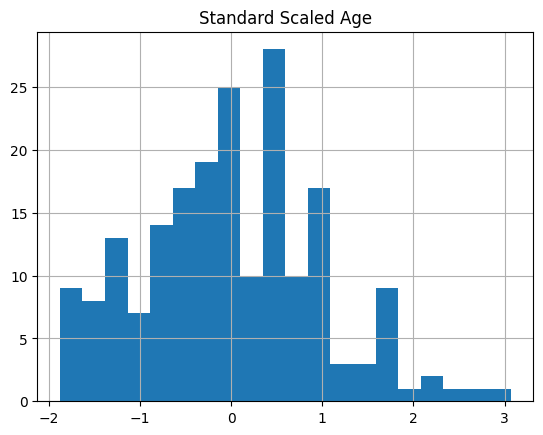

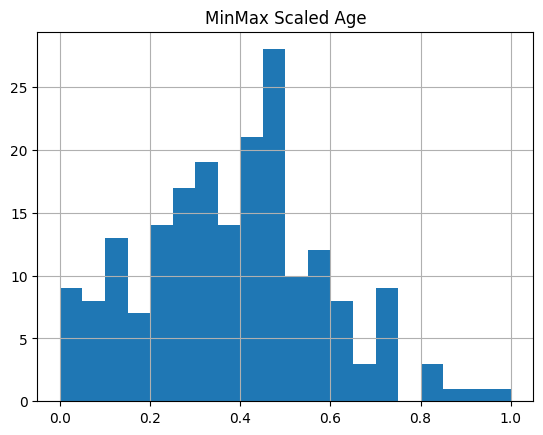

In [128]:
plt.figure()
df["age_standard"].hist(bins=20)
plt.title("Standard Scaled Age")
plt.show()

plt.figure()
df["age_minmax"].hist(bins=20)
plt.title("MinMax Scaled Age")
plt.show()

Feature scaling was applied to the age variable using StandardScaler and MinMaxScaler to normalize its magnitude. StandardScaler transformed the data to mean 0 and standard deviation 1, while MinMaxScaler scaled values between 0 and 1.